# OLS: interaction term

Suppose we are interested in estimating this CAPM-like equation:

$$
\mathbb{E}(r_t) - r_f = \alpha + \beta_{mkt} mkt_t + \beta_{rec} rec_t + \gamma mkt_t \times rec_t + \epsilon_t
$$



Our sample consists of:
-  Asset: IBM
- $mkt_t$: S\&P500
- $r_f$: 3-month T-bills
- 2010-01-01 -- 2025-01-01


## 0. Required packages

In [1]:
import yfinance as yf
import statsmodels.api as sm
from pandas_datareader import data as pdr
import matplotlib.pyplot as plt
import numpy as np

## 1. Retrieve and prepate data

We can use the `yfinance` Python package, which takes the following arguments:

- ticker
- start/end

where the IBM, S&P500, and VIX tickers are `IBM`, `^GSPC`, `^VIX`, respectively

In [2]:
# --------------------
# Inputs
# --------------------
ticker = "IBM"
market = "^GSPC"        # or "SPY"
start = "1980-01-01"
end = "2025-01-01"

fred_rf = "DGS3MO"      # 3-month T-bill (annualized %, daily)
fred_rec = "USRECD"     # NBER recession indicator (daily: 1=recession, 0=not)
trading_days = 252


# --------------------
# 1) Daily returns (stock + market)
# --------------------
px = yf.download([ticker, market], start=start, end=end, auto_adjust=True, progress=False)["Close"]

px.columns = [c.upper() for c in px.columns]

ret = px.pct_change().dropna()

# --------------------
# 2) Daily risk-free (approx): annualized % / 100 / 252
# --------------------
rf = pdr.DataReader(fred_rf, "fred", start, end).dropna()
rf["RF"] = rf[fred_rf] / 100.0 / trading_days
rf = rf[["RF"]]


# --------------------
# 3) Recession dummy (NBER)
# --------------------
rec = pdr.DataReader(fred_rec, "fred", start, end).dropna()
rec = rec.rename(columns={fred_rec: "REC"})


# --------------------
# 4) Build dataset
# --------------------
df = ret.join(rf, how="inner").join(rec, how="inner").dropna()

df["STOCK_EXCESS"] = df[ticker.upper()] - df["RF"]
df["MKT_EXCESS"] = df[market.upper()] - df["RF"]
df["REC"] = df["REC"].astype(int)

df["MKT_X_REC"] = df["MKT_EXCESS"] * df["REC"]

## 2. Estimate the model

We estimate the model using `statsmodels` API. Additionally, we correct for heteroskedasticity and autocorrelation (HAC/Newey-West SE)

In [3]:

# --------------------
# 5) Estimate CAPM with recession intercept+beta shift
# --------------------
X = sm.add_constant(df[["MKT_EXCESS", "REC", "MKT_X_REC"]])
maxlags = 5  # HAC/Newey-West
res = sm.OLS(df["STOCK_EXCESS"], X).fit(cov_type="HAC", cov_kwds={"maxlags": maxlags})

print(res.summary())

# --------------------
# 6) Report implied regimes (expansion vs recession)
# --------------------
alpha = res.params["const"]
beta = res.params["MKT_EXCESS"]
delta = res.params["REC"]
gamma = res.params["MKT_X_REC"]

print("\nImplied parameters:")
print(f"Expansion (REC=0): alpha={alpha:.6f}, beta={beta:.4f}")
print(f"Recession (REC=1): alpha={alpha+delta:.6f}, beta={beta+gamma:.4f}")

# Optional: how many recession vs expansion observations
print("\nObs counts:")
print(df["REC"].value_counts().rename(index={0: "Expansion", 1: "Recession"}))


# assumes you already estimated:
# res = OLS(STOCK_EXCESS ~ const + MKT_EXCESS + REC + MKT_X_REC)
# and you have df with columns MKT_EXCESS and REC

alpha = res.params["const"]
beta = res.params["MKT_EXCESS"]
delta = res.params["REC"]
gamma = res.params["MKT_X_REC"]

# grid of market excess returns (in your data units: daily decimal returns)
m_min = df["MKT_EXCESS"].quantile(0.01)
m_max = df["MKT_EXCESS"].quantile(0.99)
m_grid = np.linspace(m_min, m_max, 200)

# predicted lines
y_expansion = alpha + beta * m_grid                 # REC=0
y_recession = (alpha + delta) + (beta + gamma) * m_grid  # REC=1


                            OLS Regression Results                            
Dep. Variable:           STOCK_EXCESS   R-squared:                       0.382
Model:                            OLS   Adj. R-squared:                  0.382
Method:                 Least Squares   F-statistic:                     959.1
Date:                Fri, 10 Apr 2026   Prob (F-statistic):               0.00
Time:                        15:43:51   Log-Likelihood:                 31534.
No. Observations:               10821   AIC:                        -6.306e+04
Df Residuals:                   10817   BIC:                        -6.303e+04
Df Model:                           3                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const      -3.146e-06      0.000     -0.024      0.9

## 3. Plot

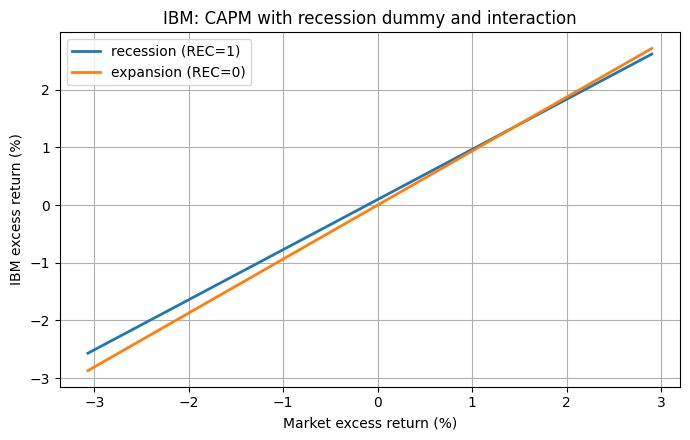

In [5]:

# plot (convert x and y to percent for readability)
plt.figure(figsize=(7, 4.5))
plt.plot(100*m_grid, 100*y_recession, linewidth=2, label="recession (REC=1)")
plt.plot(100*m_grid, 100*y_expansion, linewidth=2, label="expansion (REC=0)")

plt.xlabel("Market excess return (%)")
plt.ylabel(f"{ticker} excess return (%)")
plt.title(f"{ticker}: CAPM with recession dummy and interaction")
plt.legend()
plt.tight_layout()
plt.grid(True)
plt.show()